<a href="https://colab.research.google.com/github/helani2004/calculator-python/blob/master/Black_Friday_Sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing file

In [3]:
from google.colab import files
uploaded = files.upload()

Saving BlackFriday.csv to BlackFriday.csv


Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('BlackFriday.csv')

Step 1 — Initial Data Exploration

Dataset size
Questions to answer:

How many rows?
How many columns?

Expected:

Large dataset (~550k rows, 12 columns).

In [5]:
df.shape

(550068, 12)

Sucessful!

Preview data
Looking for:
| Column     | Meaning         |
| ---------- | --------------- |
| User_ID    | customer        |
| Product_ID | product         |
| Gender     | M/F             |
| Age        | age group       |
| Purchase   | purchase amount |


In [6]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


Sucessful!

Structure inspection

Checking :

- Data types
- Missing values
- Object vs numeric columns

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


Summary statistics
Observe:

- Purchase mean
- Min / max
- Product category ranges

Questions:

- Are purchases skewed?
- Any unusually high values?

In [8]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


Step 2 — Missing Values Analysis

In [9]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,173638


Visualizing

Expected finding:

- Product_Category_2 and Product_Category_3 contain missing values.

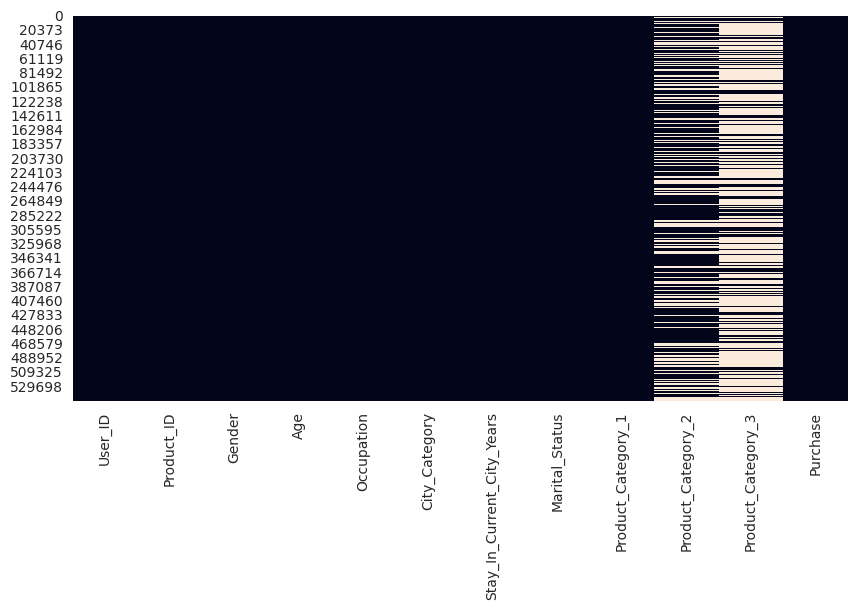

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)

plt.show()

Observations made:


- Product_Category_3 has highest missing values
- Product_Category_2 has some missing values

Step 3 — Duplicate Check

In [11]:
df.duplicated().sum()

np.int64(0)

Observation: No duplicates

Step 4 — Univariate Analysis


Purchase distribution

Questions:

- Is purchase normally distributed?
- Right skew?
- Multiple peaks?

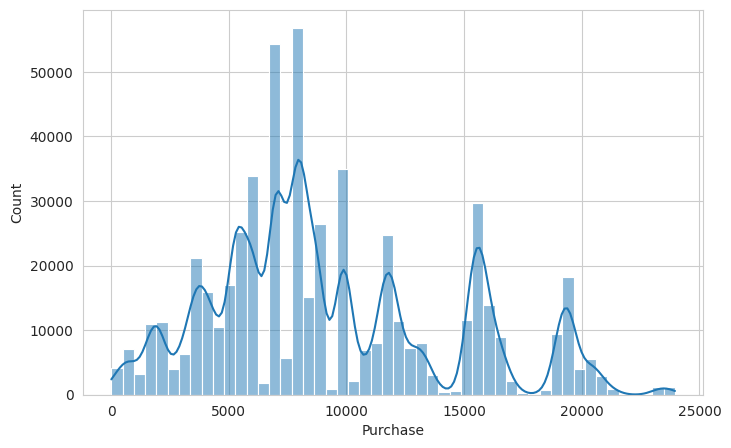

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Purchase'], bins=50, kde=True)

plt.show()

Observations:

- Is purchase normally distributed?
  No. Purchase amount does not follow a normal distribution and exhibits multiple concentration regions.

- Right skew?
  Yes, mildly right-skewed.Few customers make very high purchases.

- Multiple peaks? Yes.Possible business interpretation:

    - Customers purchase in different spending groups:
      - Budget buyers
      - Mid-range buyers
      - Premium buyers

OR

Different product categories generate different purchase bands.

Purchase boxplot

Observe:

- Outliers
- Spread

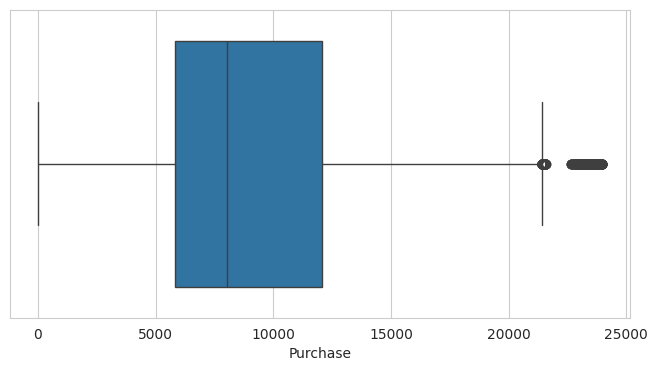

In [13]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Purchase'])

plt.show()

Purchase Boxplot Analysis:

The purchase variable shows considerable spread.

The median purchase amount is around 8k.

Most purchase values lie approximately between 6k and 12k.

Several high-value outliers are observed above 22k, indicating premium spending customers.

The distribution also supports the previously observed right skewness.

Gender distribution

Question:

Who shops more?

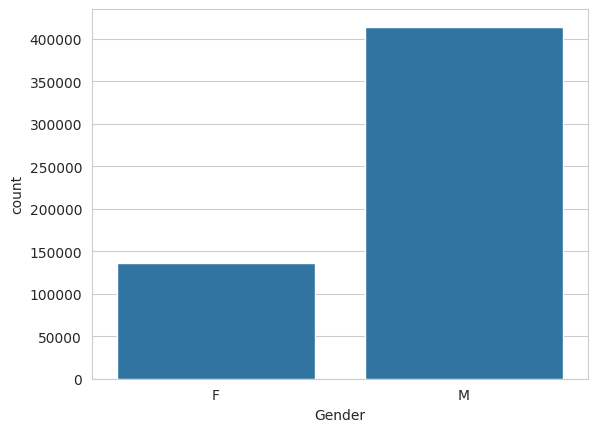

In [14]:
sns.countplot(x='Gender', data=df)

plt.show()

Gender Distribution Analysis:

Male customers dominate the dataset and account for the majority of transactions.

The number of male purchase records is approximately three times higher than female purchase records, indicating higher shopping participation among male customers.

Age groups

Questions:

- Largest customer segment?
- Young vs older buyers?

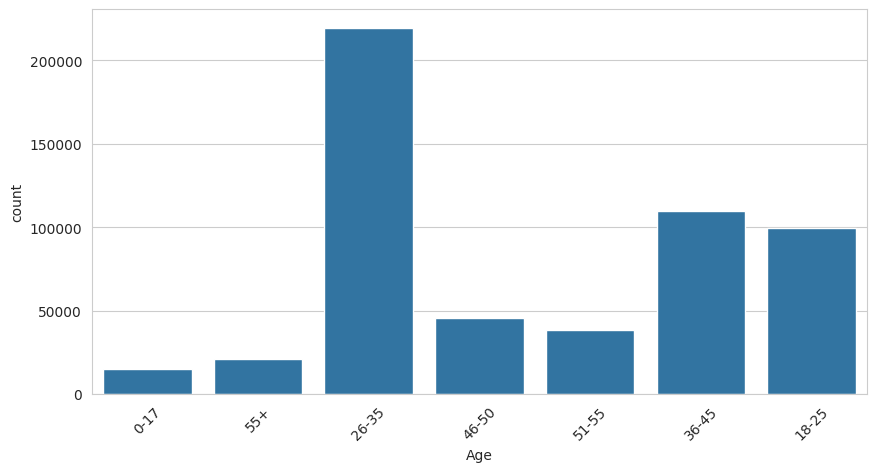

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(x='Age', data=df)

plt.xticks(rotation=45)

plt.show()

Age Distribution Analysis:

Customers aged 26–35 constitute the largest customer segment and dominate transaction volume.

Shopping participation is highest among younger and middle-aged customers and decreases progressively in older age groups.

The least represented groups are 0–17 and 55+.

Step 5 — Categorical Analysis


City category

Question

Which City group Dominates?

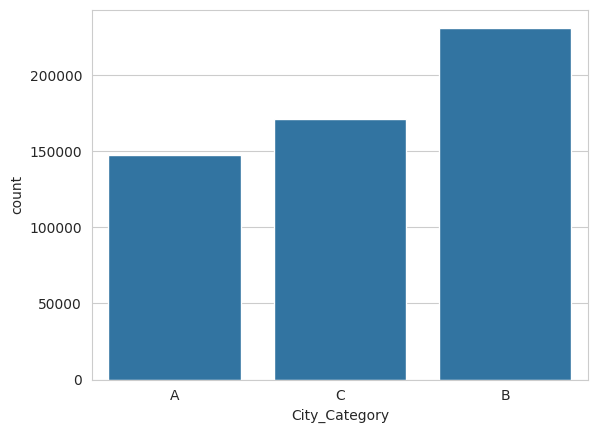

In [16]:
sns.countplot(
    x='City_Category',
    data=df
)

plt.show()

City B is dominating

Marital status

Interpret:

- 0 - Unmarried
- 1 - Married

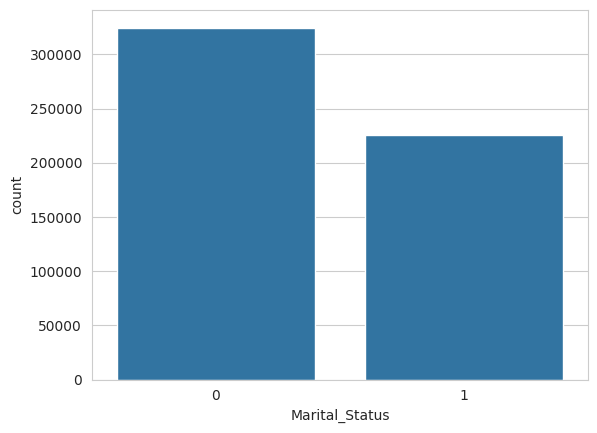

In [17]:
sns.countplot(
    x='Marital_Status',
    data=df
)

plt.show()

Observation: Higher Number of Unmarried people shops

Step 6 — Bivariate Analysis

Gender vs Purchase

Question:
- Who spends more on Average?

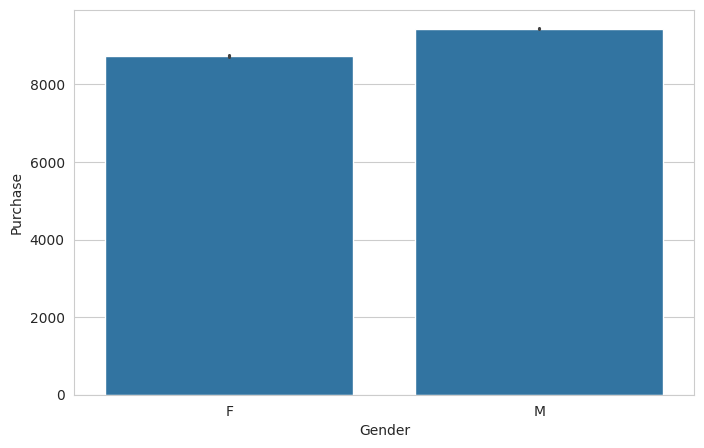

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Gender',
    y='Purchase',
    data=df
)

plt.show()

Observation - Males spends more on Average. This does not mean Males do more shopping. It could mean they go for expensive products.

Age vs Purchase

Questions:

Which age group spends most?

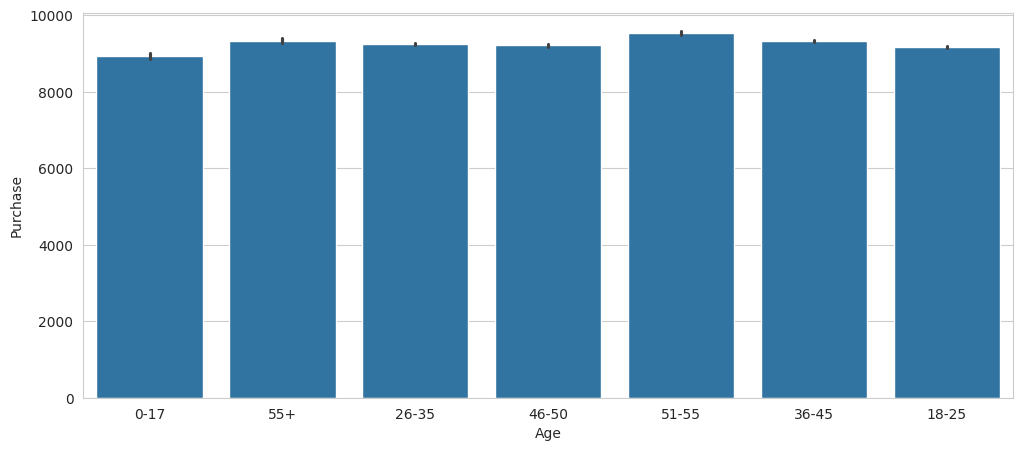

In [19]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='Age',
    y='Purchase',
    data=df
)

plt.show()

Observation:


Customers aged 51–55 exhibit the highest average purchase value.

Although the 26–35 group contributes the highest transaction count, older customers tend to spend slightly more per purchase.

Average purchase amounts remain relatively similar across all age groups.

City vs Purchase


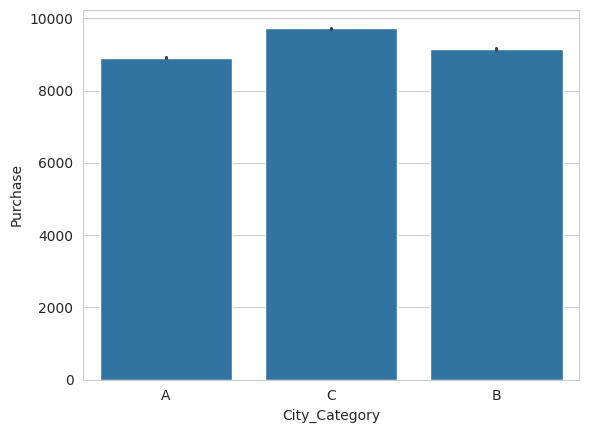

In [20]:
sns.barplot(
    x='City_Category',
    y='Purchase',
    data=df
)

plt.show()

City vs Purchase Analysis:

City Category C records the highest average purchase amount among all city groups.

Customers from City C appear to spend slightly more per transaction compared with Cities A and B.

However, purchase differences across cities remain relatively moderate.

Step 7 — Product Analysis

Most purchased categories:

Question:

Which category sells most?

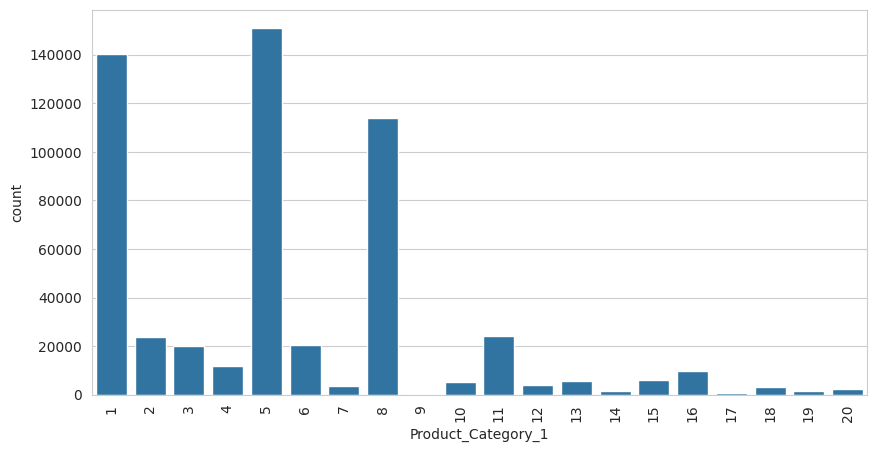

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Product_Category_1',
    data=df
)

plt.xticks(rotation=90)

plt.show()

Product Category Analysis:

Product Category 5 records the highest purchase frequency and represents the most demanded product segment.

Categories 1 and 8 also show strong customer preference.

Purchase activity is concentrated among a few product categories, while several categories exhibit relatively low transaction volume.

Purchase by category:

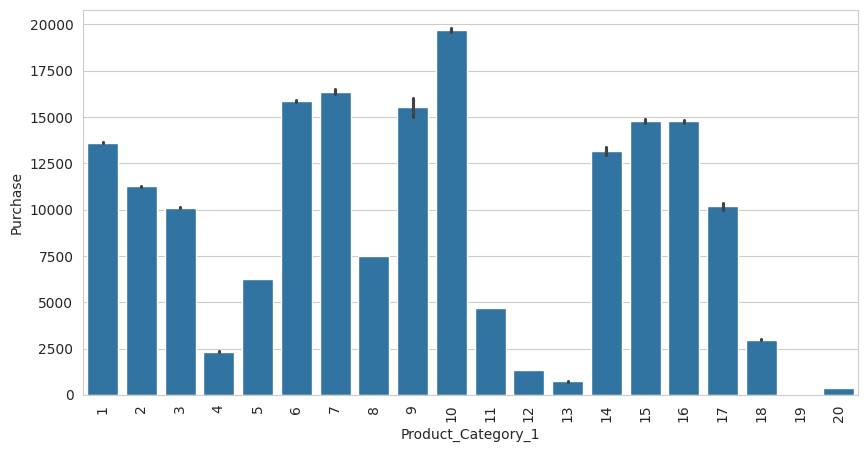

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Product_Category_1',
    y='Purchase',
    data=df
)

plt.xticks(rotation=90)

plt.show()

Purchase Value by Product Category Analysis:

Product Category 10 exhibits the highest average purchase value, indicating premium-priced products.

Although Product Category 5 records the highest sales frequency, it does not generate the highest average transaction value.

This suggests different customer behaviors between high-volume and high-value product segments.

Step 8 — Correlation Analysis

Select numeric columns:

In [23]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

Plot:

Question:

Which variables influence purchase?

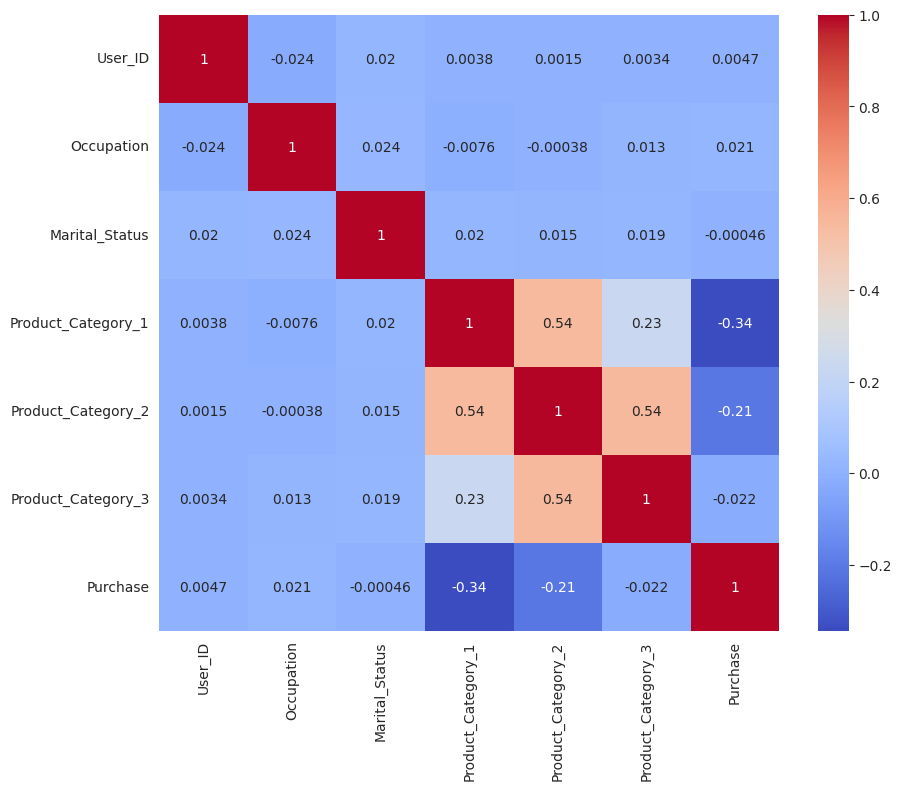

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

Correlation Analysis:

Product_Category_1 shows the strongest association with Purchase (-0.34), followed by Product_Category_2 (-0.21).

Occupation and Marital_Status exhibit negligible correlation with purchase amount.

Product categories display moderate interrelationships, particularly between Product_Category_1 and Product_Category_2.

Overall, product category appears to influence purchasing behavior more than demographic numeric variables.

Step 9 — Advanced Business Questions

Top spending age groups

In [25]:
df.groupby('Age')['Purchase'].mean().sort_values(
    ascending=False
)

,Purchase
Age,
51-55,9534.808031
55+,9336.280459
36-45,9331.350695
26-35,9252.690633
46-50,9208.625697
18-25,9169.663606
0-17,8933.464640


Top product categories

In [26]:
df.groupby(
    'Product_Category_1'
)['Purchase'].sum().sort_values(
    ascending=False
)

,Purchase
Product_Category_1,
1,1910013754
5,941835229
8,854318799
6,324150302
2,268516186
3,204084713
16,145120612
11,113791115
10,100837301


Gender spending totals

In [28]:
df.groupby(
    'Gender'
)['Purchase'].sum()

,Purchase
Gender,
F,1186232642
M,3909580100
